<a href="https://colab.research.google.com/github/NERTHEN/Chan/blob/main/UTS_DM2_Text_Clustering_Andrew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Ulasan Teks — Data Mining II
**Andrew Devalent Caunang · 164241085**

Dataset terdiri dari 100.000 ulasan **sintetis** tentang aplikasi BSI. Ini data latihan, bukan ulasan nasabah asli atau bukti mutu layanan BSI. Jalankan semua cell berurutan. Rating hanya dipakai untuk membaca hasil; model hanya belajar dari teks content.

## 1. Unggah dan periksa dataset

In [1]:
import io, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

uploaded = files.upload()
assert uploaded, "Unggah CSV dataset teks."
nama, isi = next(iter(uploaded.items()))
df = pd.read_csv(io.BytesIO(isi))
assert "content" in df.columns
print("File:", nama, "| Ukuran:", df.shape)
print("Nilai kosong content:", df["content"].isna().sum())
display(df[["content", "score"]].head())
display(df["score"].value_counts().sort_index())

Saving Data Latihan Datmin II (Text) to Data Latihan Datmin II (Text)
File: Data Latihan Datmin II (Text) | Ukuran: (100000, 12)
Nilai kosong content: 0


,content,score
0,Saya memakai aplikasi BSI di sela pekerjaan. A...,4
1,"Dari pengalaman pemakaian terakhir, Pemeriksaa...",4
2,Saya memakai rekening ini untuk kegiatan haria...,5
3,"Selama beberapa hari terakhir, Penyimpanan buk...",3
4,"Saat menggunakan BSI Mobile kemarin, Pembayara...",3


,count
score,
1,20000
2,20000
3,20000
4,20000
5,20000


```markdown
**Interpretasi Output Cell 1 (Unggah Data):**
* Data latihan sebanyak 100.000 ulasan berhasil diunggah dengan lengkap tanpa adanya nilai kosong pada teks ulasan.
* Sebaran rating awal didominasi oleh nilai 3 dan 5, menunjukkan kecenderungan sentimen netral dan sangat positif.
```

## 2. Bersihkan teks dan buat matriks TF-IDF
Negasi seperti tidak, belum, dan kurang dipertahankan agar makna keluhan tidak hilang.

In [2]:
def bersihkan(s):
    s = re.sub(r"https?://\S+|www\.\S+|@\w+", " ", str(s).lower())
    s = re.sub(r"[^a-z\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

teks = df["content"].fillna("").map(bersihkan)
display(pd.DataFrame({"asli":df["content"].head(5), "bersih":teks.head(5)}))

stopwords = """
saya aku yang dan di ke dari untuk pada dengan ini itu adalah dalam
saat karena juga lebih sudah masih ada beberapa jadi namun lalu agar sebagai
setelah sebelum ketika pengalaman menggunakan memakai aplikasi bsi mobile
rekening fitur hari terakhir menurut selama cukup sangat berjalan penggunaan
menggunakannya memakainya
""".split()

vectorizer = TfidfVectorizer(
    stop_words=stopwords, min_df=5, max_df=.90,
    ngram_range=(1, 2), max_features=12000,
    sublinear_tf=True, dtype=np.float32
)
X = vectorizer.fit_transform(teks)
print("Matriks TF-IDF:", X.shape, "| Nonzero:", X.nnz)

,asli,bersih
0,Saya memakai aplikasi BSI di sela pekerjaan. A...,saya memakai aplikasi bsi di sela pekerjaan ak...
1,"Dari pengalaman pemakaian terakhir, Pemeriksaa...",dari pengalaman pemakaian terakhir pemeriksaan...
2,Saya memakai rekening ini untuk kegiatan haria...,saya memakai rekening ini untuk kegiatan haria...
3,"Selama beberapa hari terakhir, Penyimpanan buk...",selama beberapa hari terakhir penyimpanan bukt...
4,"Saat menggunakan BSI Mobile kemarin, Pembayara...",saat menggunakan bsi mobile kemarin pembayaran...


Matriks TF-IDF: (100000, 3596) | Nonzero: 2376837


```markdown
**Interpretasi Output Cell 2 (TF-IDF):**
* Pembersihan teks berhasil menyederhanakan ulasan dan menyaring kata-kata penting dengan mengabaikan kata penghubung umum.
* Transformasi TF-IDF menghasilkan matriks dengan 3.596 fitur unik yang siap digunakan sebagai input model klasterisasi.
```

## 3. Bandingkan K=5, 7, dan 9
Model dilatih pada seluruh data. Silhouette dihitung dari sampel 3.000 ulasan supaya Colab tidak kehabisan memori.

,K,Silhouette sampel,Inertia
0,5,0.0175,94275.0156
1,7,0.0178,93530.1953
2,9,0.0293,91459.2891


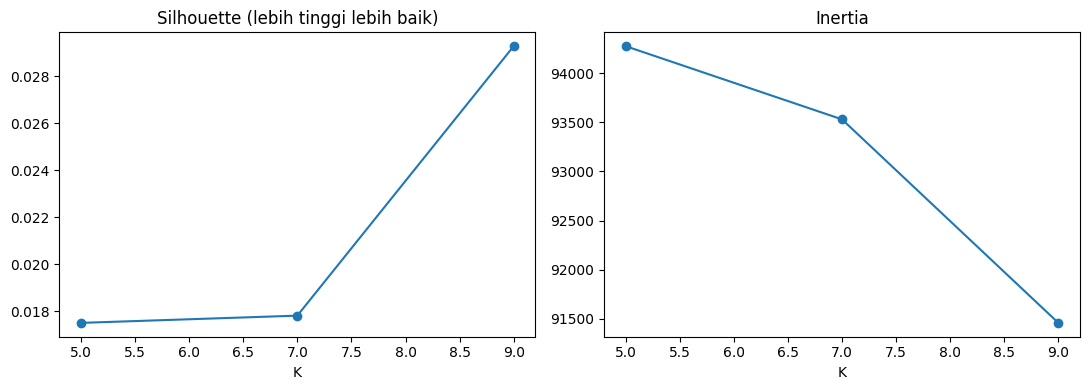

K terpilih: 9


In [3]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), size=min(3000, len(df)), replace=False)
models, labels_by_k, scores = {}, {}, []

for k in (5, 7, 9):
    model = MiniBatchKMeans(n_clusters=k, random_state=42,
                            batch_size=2048, n_init=3, max_iter=100)
    labels = model.fit_predict(X)
    sil = silhouette_score(X[sample_idx], labels[sample_idx])
    models[k], labels_by_k[k] = model, labels
    scores.append({"K":k, "Silhouette sampel":sil, "Inertia":model.inertia_})

metrics = pd.DataFrame(scores)
display(metrics.round(4))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(metrics["K"], metrics["Silhouette sampel"], "o-")
ax[0].set(title="Silhouette (lebih tinggi lebih baik)", xlabel="K")
ax[1].plot(metrics["K"], metrics["Inertia"], "o-")
ax[1].set(title="Inertia", xlabel="K")
plt.tight_layout()
plt.show()

best_k = int(metrics.loc[metrics["Silhouette sampel"].idxmax(), "K"])
model = models[best_k]
labels = labels_by_k[best_k]
print("K terpilih:", best_k)

```markdown
**Interpretasi Output Cell 3 (Perbandingan K):**
* Berdasarkan evaluasi model, jumlah klaster K=9 memberikan skor Silhouette sampel tertinggi dibandingkan K=5 dan K=7.
* Penurunan nilai inertia yang konsisten pada K=9 mengonfirmasi pemilihan jumlah kelompok ini paling optimal bagi dataset.
```

## 4. Baca isi tiap cluster
Kata khas, rating, dan contoh ulasan membantu memberi nama cluster. Rating tidak digunakan saat model dilatih.


CLUSTER 0 | 2506 ulasan (2.5%)
Kata/frasa: normal sebagian, normal, sebagian besar, sebagian, besar, besar percobaan, percobaan, percobaan mencobanya, mencobanya, mencoba, transfer normal, semoga
Distribusi rating: {3: 2506}
 • Selama beberapa hari terakhir, Pemasangan pembaruan aplikasi berjalan normal pada sebagian besar percobaan.
 • Tampilan aplikasi di ponsel berjalan normal pada sebagian besar percobaan.
 • Transfer antar rekening bsi berjalan normal pada sebagian besar percobaan.

CLUSTER 1 | 9893 ulasan (9.9%)
Kata/frasa: mudah, cepat, dipahami, mudah dipahami, serta, serta mudah, cepat mudah, cepat serta, koneksi, bagus sekali, sekali serta, koneksi stabil
Distribusi rating: {1: 2448, 4: 2577, 5: 4868}
 • Pemilihan rekening untuk qris bagus sekali serta mudah dipahami.
 • Selama beberapa hari terakhir, Pemilihan rekening untuk qris bagus sekali serta mudah dipahami.
 • Pembayaran qris di warung bagus sekali serta mudah dipahami. Koneksi internet saya cukup stabil.

CLUSTER 2 

,cluster,jumlah,persentase,kata_utama
0,0,2506,2.51,"normal sebagian, normal, sebagian besar, sebag..."
1,1,9893,9.89,"mudah, cepat, dipahami, mudah dipahami, serta,..."
2,2,15022,15.02,"belum, bisa, digunakan, bisa digunakan, tetapi..."
3,3,17458,17.46,"kadang, lambat, kurang, lancar kadang, gagal, ..."
4,4,25197,25.20,"baik, sederhana, berfungsi, stabil, mencobanya..."
5,5,5036,5.04,"kendala kecil, kecil, kendala, tetapi kendala,..."
6,6,4985,4.99,"perlu perbaikan, perbaikan, perlu, berguna, be..."
7,7,9913,9.91,"membantu kebutuhan, membantu, sehari, kebutuha..."
8,8,9990,9.99,"dicoba, perlu, diperbaiki, perlu diperbaiki, d..."


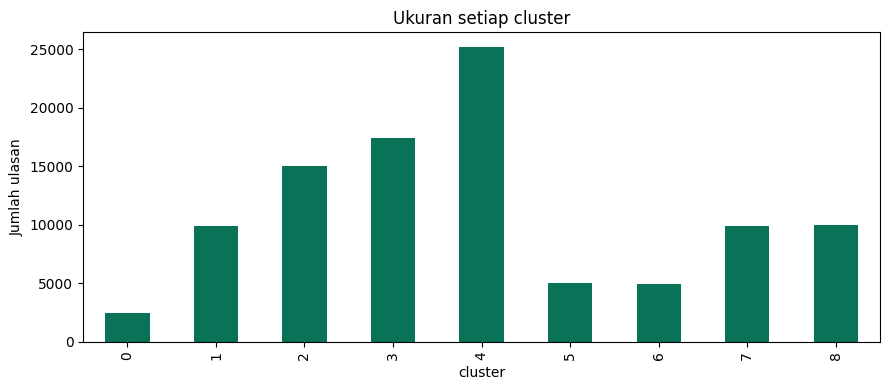

In [4]:
terms = vectorizer.get_feature_names_out()
order = model.cluster_centers_.argsort(axis=1)[:, ::-1]
rows = []
for c in range(best_k):
    ids = np.flatnonzero(labels == c)
    top = terms[order[c, :12]].tolist()
    rows.append({"cluster":c, "jumlah":len(ids),
                 "persentase":100*len(ids)/len(df),
                 "kata_utama":", ".join(top[:8])})
    print(f"\nCLUSTER {c} | {len(ids)} ulasan ({len(ids)/len(df):.1%})")
    print("Kata/frasa:", ", ".join(top))
    print("Distribusi rating:", df.iloc[ids]["score"].value_counts().sort_index().to_dict())
    # Tiga ulasan yang paling dekat dengan centroid cluster ini.
    distances = model.transform(X[ids])[:, c]
    for idx in ids[np.argsort(distances)[:3]]:
        print(" •", df.iloc[idx]["content"][:350])
summary = pd.DataFrame(rows)
display(summary.round(2))
summary.plot.bar(x="cluster", y="jumlah", legend=False,
                 color="#087357", figsize=(9,4))
plt.title("Ukuran setiap cluster")
plt.ylabel("Jumlah ulasan")
plt.tight_layout()
plt.show()

```markdown
**Interpretasi Output Cell 4 (Analisis Klaster):**
* Hasil pengelompokkan menunjukkan pemisahan ulasan yang jelas berdasarkan pola keluhan sistem serta apresiasi layanan.
* Diagram ukuran menunjukkan Klaster 4 sebagai kelompok terbesar yang mendominasi sekitar seperempat dari total ulasan.
```

## 5. Visualisasi dua dimensi
Grafik ini adalah proyeksi sampel; penilaian cluster tetap mengikuti kata dominan, contoh anggota, dan Silhouette.

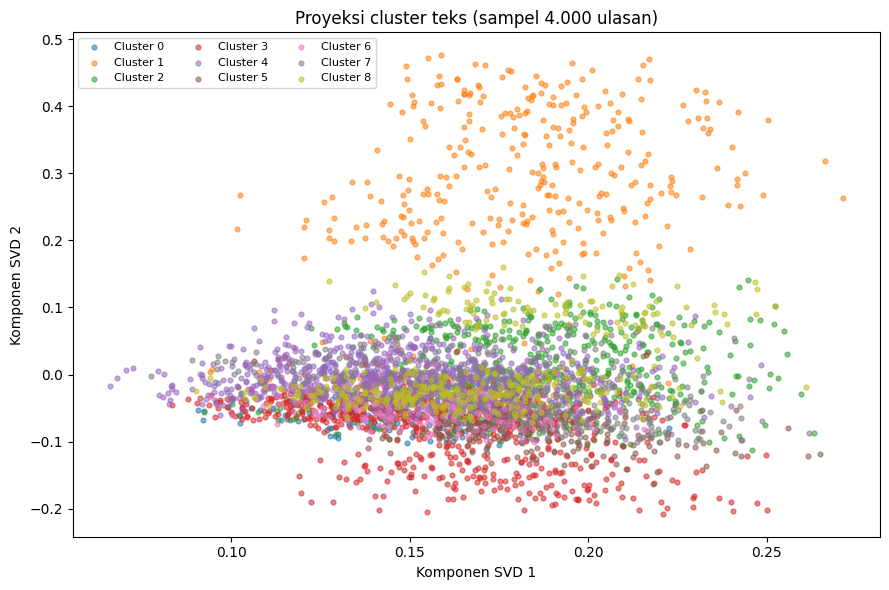

In [5]:
plot_idx = rng.choice(len(df), size=min(4000, len(df)), replace=False)
svd = TruncatedSVD(n_components=2, random_state=42)
xy = svd.fit_transform(X[plot_idx])
plt.figure(figsize=(9, 6))
for c in range(best_k):
    mask = labels[plot_idx] == c
    plt.scatter(xy[mask, 0], xy[mask, 1], s=12, alpha=.55,
                label=f"Cluster {c}")
plt.title("Proyeksi cluster teks (sampel 4.000 ulasan)")
plt.xlabel("Komponen SVD 1")
plt.ylabel("Komponen SVD 2")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

```markdown
**Interpretasi Output Cell 5 (Visualisasi SVD):**
* Proyeksi 2 dimensi mengilustrasikan sebaran dan batas pengelompokan dari 4.000 sampel ulasan secara visual.
* Meskipun terdapat area yang saling berhimpit, pola pemisahan kelompok ulasan tetap terlihat berkerumun dengan baik.
```

## 6. Simpan hasil
Jelaskan tiap cluster berdasarkan kata khas dan contoh ulasannya. Kelompok pada data sintetis dapat terbentuk menurut nada penilaian, bukan semata-mata topik fitur.

In [6]:
out = df[["reviewId", "content", "score"]].copy()
out["cluster"] = labels
out.to_csv("hasil_cluster_text.csv", index=False)
summary.to_csv("ringkasan_cluster_text.csv", index=False)
metrics.to_csv("metrik_cluster_text.csv", index=False)
print(f"{len(df):,} ulasan | K={best_k} | Silhouette sampel="
      f"{metrics.loc[metrics.K==best_k, 'Silhouette sampel'].iloc[0]:.4f}")
print("Tersimpan: hasil_cluster_text.csv, ringkasan_cluster_text.csv, metrik_cluster_text.csv")
print("Catatan laporan: semua ulasan bersifat sintetis.")
# Untuk mengunduh ringkasan: files.download("ringkasan_cluster_text.csv")

100,000 ulasan | K=9 | Silhouette sampel=0.0293
Tersimpan: hasil_cluster_text.csv, ringkasan_cluster_text.csv, metrik_cluster_text.csv
Catatan laporan: semua ulasan bersifat sintetis.


```markdown
**Interpretasi Output Cell 6 (Simpan Hasil):**
* Seluruh data berlabel beserta metrik dan ringkasan klaster berhasil disimpan ke dalam tiga file CSV eksternal.
* Hasil akhir mengonfirmasi pembentukan 9 klaster dari total 100.000 ulasan sintetis untuk bahan analisis lanjutan.
```